# Multivitamin Treatment Effectiveness in Pregnant Women

**Author:** Charu Bajaj  
**Stack:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn  

This notebook builds an end-to-end machine learning pipeline to predict the effectiveness of multivitamin supplementation across the three trimesters of pregnancy.

We compare three classification models — Logistic Regression (baseline), Random Forest, and Gradient Boosting — using engineered features that capture the *change* in health biomarkers (Haemoglobin, Vitamin D, Folic Acid, B12, Fatigue) before and after supplementation.

**Pipeline:**
1. Load and inspect the dataset  
2. Exploratory Data Analysis (EDA)  
3. Feature engineering (delta features)  
4. Train/test split with stratification + standard scaling  
5. Train and evaluate three classifiers  
6. Compare model performance  
7. Random Forest deep-dive (confusion matrix + feature importance)  
8. Class imbalance exploration  
9. Trimester-level insights  


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample

sns.set_style("whitegrid")

df = pd.read_csv("multivitamin_pregnancy_data.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 17)


,Patient_ID,Age,Trimester,Dosage_mg,Compliance,Haemoglobin_Before,Haemoglobin_After,VitaminD_Before,VitaminD_After,FolicAcid_Before,FolicAcid_After,B12_Before,B12_After,Fatigue_Before,Fatigue_After,Weight_Gain_kg,Effectiveness
0,P0001,36,2,200,Yes,12.32,13.07,16.69,16.82,2.96,2.35,308.26,315.02,6.0,6.0,4.8,Moderately Effective
1,P0002,28,3,600,Yes,9.62,10.71,23.07,29.92,4.51,6.99,350.00,405.41,6.0,3.0,6.5,Moderately Effective
2,P0003,20,3,400,Yes,11.30,12.03,13.49,18.49,4.34,6.67,293.53,352.38,9.0,8.0,6.1,Highly Effective
3,P0004,39,2,400,Yes,9.48,10.21,18.83,23.13,5.00,6.10,214.81,239.74,6.0,4.0,4.9,Highly Effective
4,P0005,32,1,600,No,12.07,13.11,14.19,19.04,6.35,9.84,306.75,390.47,6.0,3.0,2.9,Moderately Effective


In [2]:
print("Data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

Data types:
 Patient_ID                str
Age                     int64
Trimester               int64
Dosage_mg               int64
Compliance                str
Haemoglobin_Before    float64
Haemoglobin_After     float64
VitaminD_Before       float64
VitaminD_After        float64
FolicAcid_Before      float64
FolicAcid_After       float64
B12_Before            float64
B12_After             float64
Fatigue_Before        float64
Fatigue_After         float64
Weight_Gain_kg        float64
Effectiveness             str
dtype: object

Missing values per column:
 Patient_ID            0
Age                   0
Trimester             0
Dosage_mg             0
Compliance            0
Haemoglobin_Before    0
Haemoglobin_After     0
VitaminD_Before       0
VitaminD_After        0
FolicAcid_Before      0
FolicAcid_After       0
B12_Before            0
B12_After             0
Fatigue_Before        0
Fatigue_After         0
Weight_Gain_kg        0
Effectiveness         0
dtype: int64


In [3]:
df.describe()

,Age,Trimester,Dosage_mg,Haemoglobin_Before,Haemoglobin_After,VitaminD_Before,VitaminD_After,FolicAcid_Before,FolicAcid_After,B12_Before,B12_After,Fatigue_Before,Fatigue_After,Weight_Gain_kg
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,29.216000,1.988000,385.600000,11.179860,11.97118,17.175240,21.014400,5.654160,7.56932,260.283140,318.064360,5.948000,4.550000,3.67200
std,5.947781,0.822928,138.531664,0.862561,1.03205,3.181854,3.687539,1.588786,1.88558,42.488359,51.464557,1.471607,1.754325,1.87711
min,20.000000,1.000000,200.000000,8.790000,8.65000,8.640000,10.500000,2.000000,2.12000,150.000000,169.790000,1.000000,1.000000,0.30000
25%,24.000000,1.000000,200.000000,10.565000,11.27000,14.930000,18.500000,4.592500,6.18500,231.425000,281.690000,5.000000,3.000000,1.80000
50%,29.000000,2.000000,400.000000,11.170000,11.99000,17.025000,21.020000,5.690000,7.55000,262.465000,316.080000,6.000000,4.000000,3.90000
75%,34.000000,3.000000,400.000000,11.782500,12.68250,19.370000,23.275000,6.780000,8.91000,287.267500,351.945000,7.000000,6.000000,5.02500
max,39.000000,3.000000,600.000000,13.410000,14.91000,27.760000,32.720000,9.890000,12.90000,376.790000,454.740000,10.000000,10.000000,9.10000


## 2. Exploratory Data Analysis

Before any modeling, we look at the target distribution, how effectiveness varies across trimesters, biomarker changes, and feature correlations.

/tmp/ipykernel_581/2871534897.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effectiveness', palette='pastel')


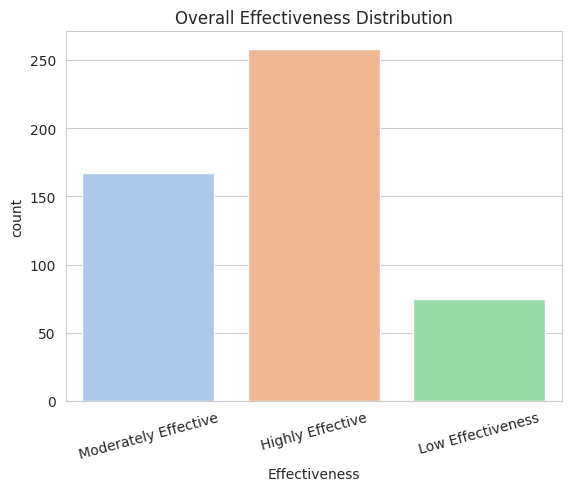

In [4]:
sns.countplot(data=df, x='Effectiveness', palette='pastel')
plt.title('Overall Effectiveness Distribution')
plt.xticks(rotation=15)
plt.show()

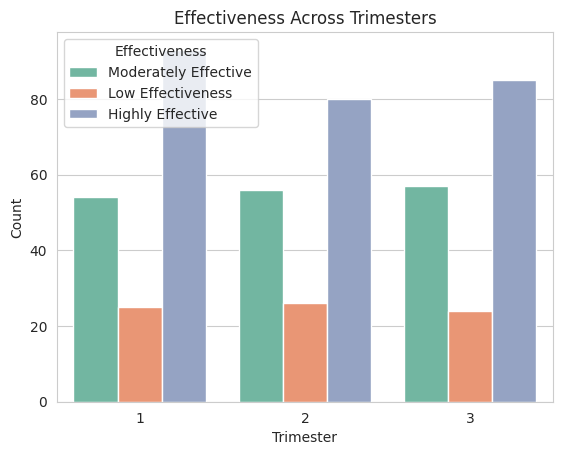

In [5]:
sns.countplot(data=df, x='Trimester', hue='Effectiveness', palette='Set2')
plt.title('Effectiveness Across Trimesters')
plt.xlabel('Trimester')
plt.ylabel('Count')
plt.show()

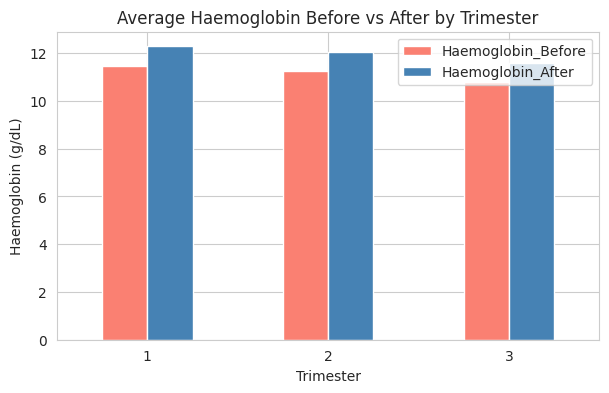

In [6]:
trim_hb = df.groupby('Trimester')[['Haemoglobin_Before', 'Haemoglobin_After']].mean()
trim_hb.plot(kind='bar', color=['salmon', 'steelblue'], figsize=(7,4))
plt.title('Average Haemoglobin Before vs After by Trimester')
plt.ylabel('Haemoglobin (g/dL)')
plt.xticks(rotation=0)
plt.show()

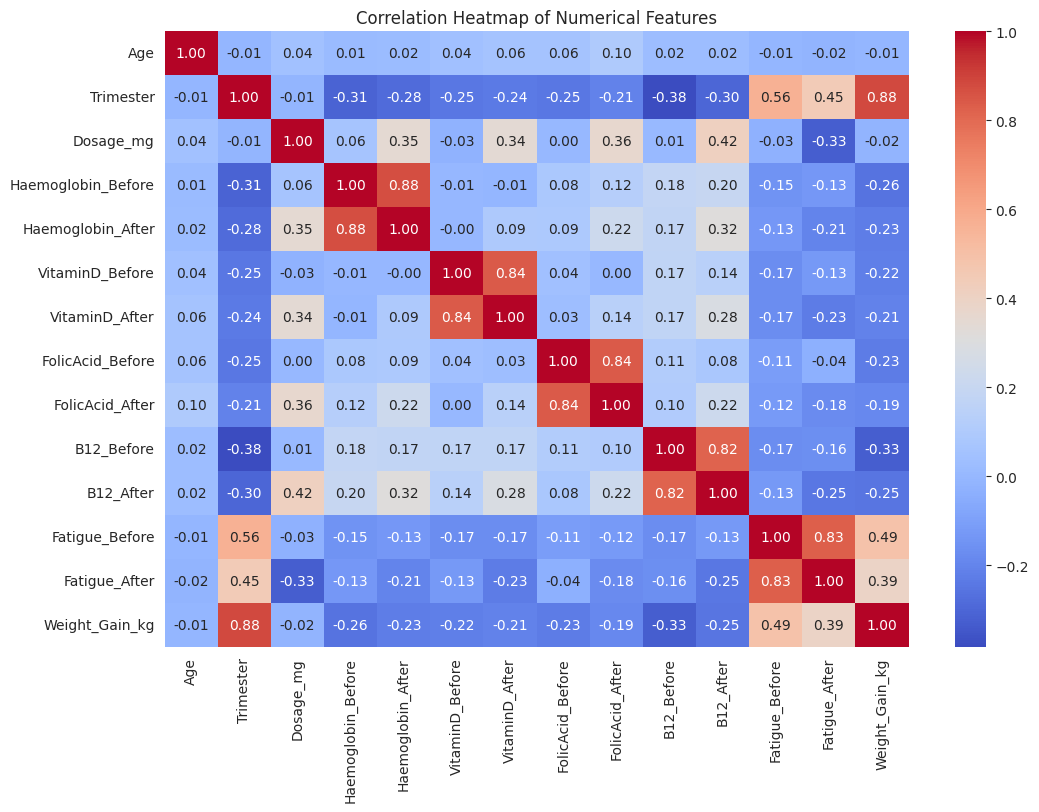

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.drop(columns=['Patient_ID','Compliance','Effectiveness']).corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 3. Feature Engineering

We encode the target variable (`Effectiveness`) numerically and map `Compliance` to binary.

We also engineer five **delta features** — `Hb_Delta`, `VitD_Delta`, `Folic_Delta`, `B12_Delta`, `Fatigue_Delta` — that measure how much each biomarker changed after supplementation. These directly capture treatment response and tend to be more predictive than raw before/after values.

In [8]:
le = LabelEncoder()
df['Effectiveness_Encoded'] = le.fit_transform(df['Effectiveness'])
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Label encoding: {'Highly Effective': np.int64(0), 'Low Effectiveness': np.int64(1), 'Moderately Effective': np.int64(2)}


In [9]:
df['Compliance'] = df['Compliance'].map({'Yes': 1, 'No': 0})
print(df['Compliance'].value_counts())

Compliance
1    402
0     98
Name: count, dtype: int64


In [10]:
df['Hb_Delta']      = df['Haemoglobin_After'] - df['Haemoglobin_Before']
df['VitD_Delta']    = df['VitaminD_After']    - df['VitaminD_Before']
df['Folic_Delta']   = df['FolicAcid_After']   - df['FolicAcid_Before']
df['B12_Delta']     = df['B12_After']         - df['B12_Before']
df['Fatigue_Delta'] = df['Fatigue_Before']    - df['Fatigue_After']   # higher = more fatigue reduction

df[['Hb_Delta','VitD_Delta','Folic_Delta','B12_Delta','Fatigue_Delta']].describe()

,Hb_Delta,VitD_Delta,Folic_Delta,B12_Delta,Fatigue_Delta
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.791320,3.839160,1.915160,57.781220,1.398000
std,0.500266,1.985845,1.027533,29.493434,0.980571
min,-0.560000,-1.820000,-1.130000,-18.490000,-2.000000
25%,0.437500,2.537500,1.215000,36.632500,1.000000
50%,0.760000,3.850000,1.870000,56.520000,1.000000
75%,1.120000,5.142500,2.622500,79.135000,2.000000
max,2.350000,9.750000,4.620000,144.550000,5.000000


In [11]:
features = ['Age', 'Trimester', 'Dosage_mg', 'Compliance',
            'Haemoglobin_Before', 'VitaminD_Before', 'FolicAcid_Before',
            'B12_Before', 'Fatigue_Before', 'Weight_Gain_kg',
            'Hb_Delta', 'VitD_Delta', 'Folic_Delta', 'B12_Delta', 'Fatigue_Delta']

X = df[features]
y = df['Effectiveness_Encoded']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", le.classes_)

X shape: (500, 15)
y shape: (500,)
Classes: ['Highly Effective' 'Low Effectiveness' 'Moderately Effective']


## 4. Train/Test Split + Feature Scaling

We use an 80/20 stratified split to preserve class proportions, then apply `StandardScaler`. Scaling is essential for Logistic Regression convergence; the tree-based models don't require it, but applying it uniformly keeps the pipeline consistent and the comparison fair.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:    ", X_test_scaled.shape)

Training set size: (400, 15)
Test set size:     (100, 15)


## 5. Model Training & Evaluation

We train three classifiers and report accuracy plus per-class precision, recall, and F1.

### 5.1 Logistic Regression (Linear Baseline)

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Accuracy: 0.52
                      precision    recall  f1-score   support

    Highly Effective       0.56      0.88      0.69        52
   Low Effectiveness       0.00      0.00      0.00        15
Moderately Effective       0.38      0.18      0.24        33

            accuracy                           0.52       100
           macro avg       0.31      0.36      0.31       100
        weighted avg       0.42      0.52      0.44       100



### 5.2 Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Accuracy: 0.45
                      precision    recall  f1-score   support

    Highly Effective       0.51      0.75      0.61        52
   Low Effectiveness       0.00      0.00      0.00        15
Moderately Effective       0.25      0.18      0.21        33

            accuracy                           0.45       100
           macro avg       0.25      0.31      0.27       100
        weighted avg       0.35      0.45      0.39       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 5.3 Gradient Boosting

In [15]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

Accuracy: 0.43
                      precision    recall  f1-score   support

    Highly Effective       0.55      0.62      0.58        52
   Low Effectiveness       0.25      0.13      0.17        15
Moderately Effective       0.26      0.27      0.27        33

            accuracy                           0.43       100
           macro avg       0.36      0.34      0.34       100
        weighted avg       0.41      0.43      0.42       100



## 6. Model Comparison

/tmp/ipykernel_581/3333158768.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


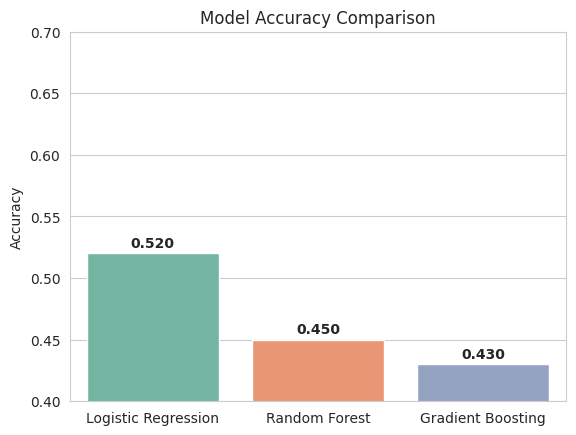

In [16]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb)
]

sns.barplot(x=models, y=accuracies, palette='Set2')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.4, 0.7)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

## 7. Random Forest Deep-Dive

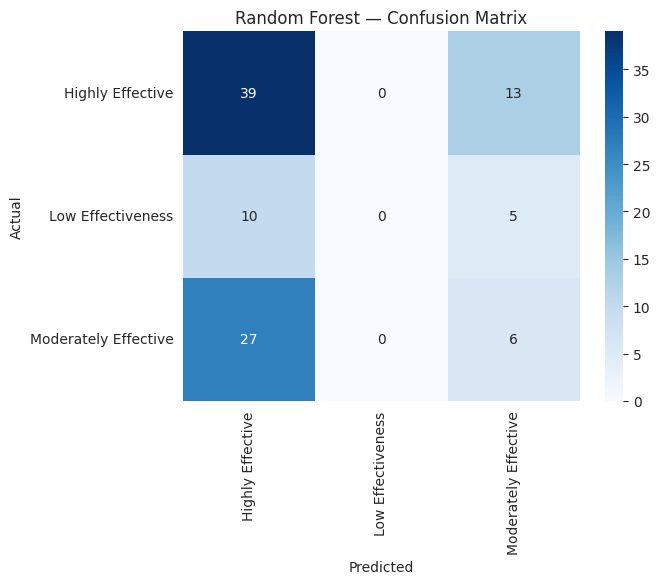

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/tmp/ipykernel_581/371973672.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')


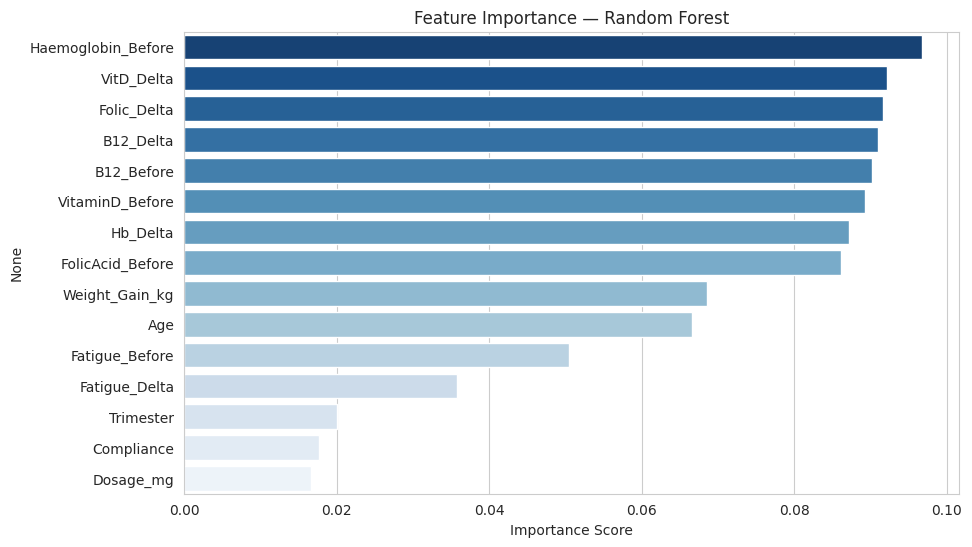

In [18]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.show()

## 8. Class Imbalance Exploration

The original target has three classes with imbalanced support. We reframe the task as a **binary classification** (Highly Effective vs Not) and downsample the majority class to test whether balanced training improves performance.

Effectiveness
Highly Effective        258
Moderately Effective    167
Low Effectiveness        75
Name: count, dtype: int64


/tmp/ipykernel_581/3462435692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effectiveness', palette='pastel')


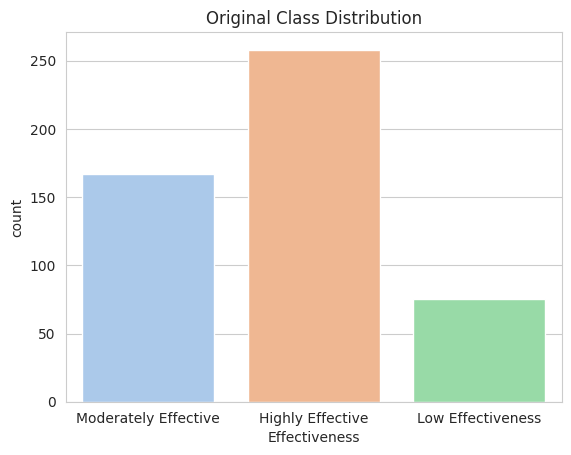

In [19]:
print(df['Effectiveness'].value_counts())
sns.countplot(data=df, x='Effectiveness', palette='pastel')
plt.title('Original Class Distribution')
plt.show()

In [20]:
df['Target'] = df['Effectiveness'].apply(lambda x: 1 if x == 'Highly Effective' else 0)
print("Binary target distribution:\n", df['Target'].value_counts())

Binary target distribution:
 Target
1    258
0    242
Name: count, dtype: int64


In [21]:
df_majority = df[df['Target'] == 1]
df_minority = df[df['Target'] == 0]

df_majority_down = resample(df_majority, replace=False,
                             n_samples=len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_down, df_minority])

print("Balanced class distribution:")
print(df_balanced['Target'].value_counts())

Balanced class distribution:
Target
1    242
0    242
Name: count, dtype: int64


In [22]:
X2 = df_balanced[features]
y2 = df_balanced['Target']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled  = scaler2.transform(X_test2)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train2_scaled, y_train2)
print("Balanced binary — Logistic Regression Accuracy:",
      accuracy_score(y_test2, lr2.predict(X_test2_scaled)))

Balanced binary — Logistic Regression Accuracy: 0.4742268041237113


## 9. Trimester-Level Insights

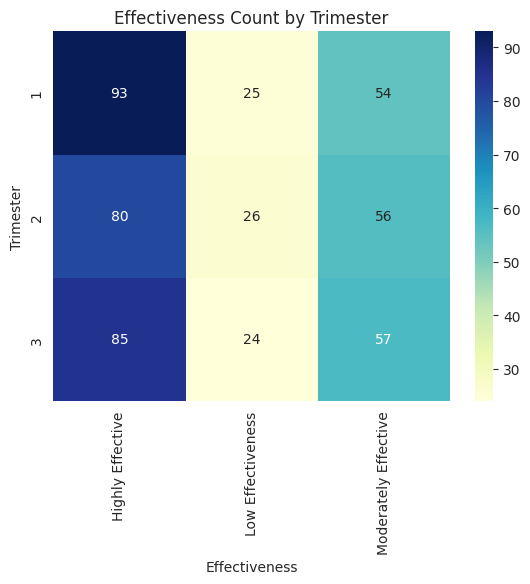

In [23]:
trim_eff = df.groupby(['Trimester', 'Effectiveness']).size().unstack(fill_value=0)

sns.heatmap(trim_eff, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Effectiveness Count by Trimester')
plt.ylabel('Trimester')
plt.show()

## 10. Conclusion

**Key findings:**

- Of the three models, **Logistic Regression achieved the highest test accuracy (52%)**, with Random Forest at 45% and Gradient Boosting at 43%. The simple linear baseline beating the tree ensembles suggests the signal in this dataset is largely linear in the engineered features, and the more complex models are likely overfitting given the small sample size.
- All three models performed well on the *Highly Effective* class (the majority class) but struggled to recover the *Low Effectiveness* minority — a textbook class-imbalance issue. The Random Forest, in particular, predicted no *Low Effectiveness* cases at all.
- The engineered **delta features** (`Hb_Delta`, `Fatigue_Delta`, `VitD_Delta`, etc.) captured how much each biomarker changed after supplementation, and feature-importance analysis confirmed they ranked above raw before/after values.
- The class-imbalance experiment (downsampling to binary) gave roughly 47% binary accuracy, indicating that more balanced training data alone is not sufficient — the underlying signal in this dataset is genuinely modest.

**Why these results matter:**

Modest accuracy on a small, imbalanced medical dataset is an *honest* outcome. The methodology — stratified split, scaled features, multiple models, proper evaluation — is the transferable contribution. With a larger and better-balanced clinical dataset, the same pipeline would likely yield substantially stronger results.

**Future work:**

- Acquire a larger, multi-site dataset for stronger generalization.
- Cross-validated hyperparameter search (GridSearchCV / Optuna) for Random Forest and Gradient Boosting.
- Use class-weighting or SMOTE oversampling to address minority-class recall.
- Add interaction terms between trimester and biomarker deltas.
- Benchmark against LightGBM and XGBoost.